In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import LigandEnvironment, Receptor, generate_receptor_indices, plot_family_summary,LogNormalConcentration,plot_latent_radar_chart,evaluate_model
from objectives import ExactInformationLoss,ProxyInformationLoss


In [2]:
CONF = {
        "n_units": 2,
        "n_families": 5,
        "latent_dim": 5,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "k_knn":5
    }

In [3]:
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], 
                        CONF['n_families'], 
                        conc_model=conc_strategy,
                        latent_dim=CONF['latent_dim']).to(device)

physics = Receptor(CONF["n_units"], CONF["k_sub"]).to(device)
#loss_fn = ProxyInformationLoss(cov_weight=CONF['cov_weight']) # Default bandwidth
loss_fn = ExactInformationLoss(k_knn=CONF['k_knn']) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
#receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1],[0,0,1,1,1]],dtype=torch.long)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)
print(receptor_indices)

# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])


tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1]])


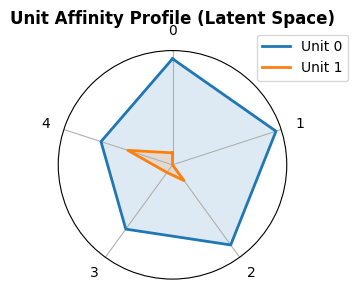

In [4]:
fig,ax = plot_latent_radar_chart(env, unit_indices=[0, 1], 
                        family_names=[str(i) for i in range(CONF['n_families'])])

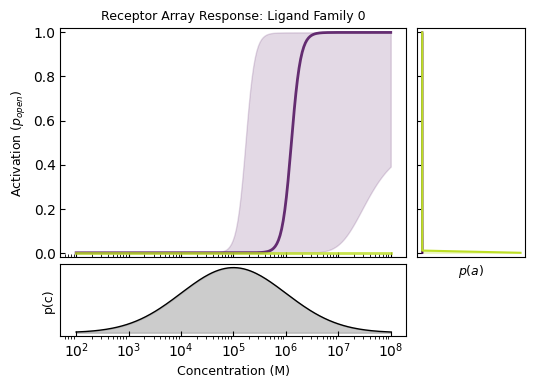

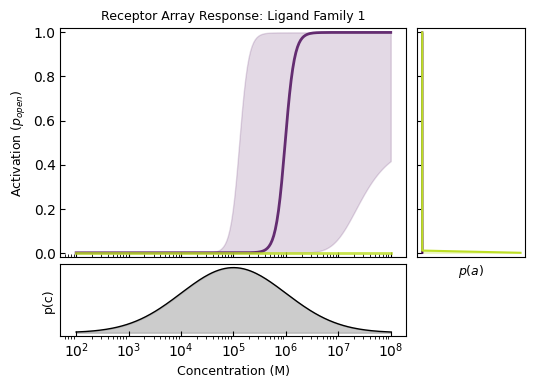

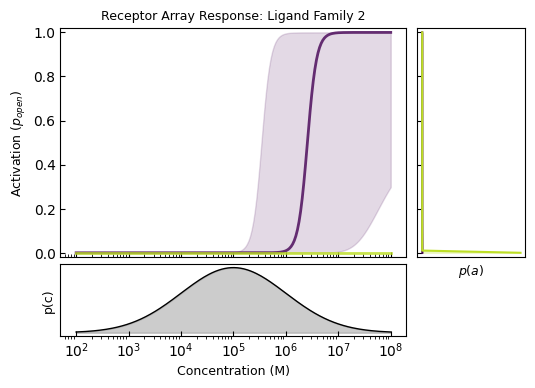

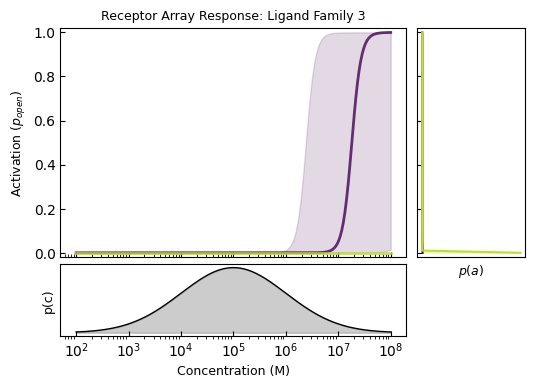

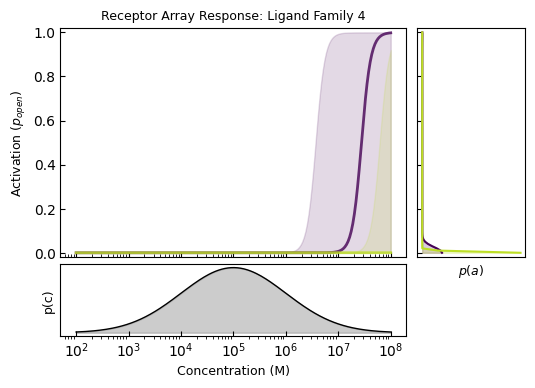

In [5]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)
#with torch.no_grad():
#    E_o = env.interaction_mu.cpu()[:,:,0]
#    E_c = env.interaction_mu.cpu()[:,:,1]
#    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
#for i in range(axes.__len__()):
#    axes[i][0].plot([10**2,10**8],[asymptot[0][i],asymptot[0][i]])
#figs[0].savefig('no_opti_1r_1l.svg',bbox_inches='tight')

In [6]:
# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")

stats_1_hetero = []
for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    
    if epoch % 10 == 0:
        stats_1_hetero.append(loss_fn.make_stats(activity))
#stats = np.array(stats)
#stats = {
#            "full_array_entropy":stats[:,0],
#            "marginal_entropy":stats[:,1],
#            "total_correlation":stats[:,2]
#        }


Training for 600 epochs...


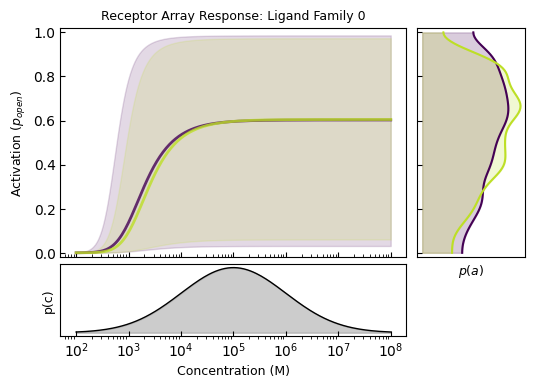

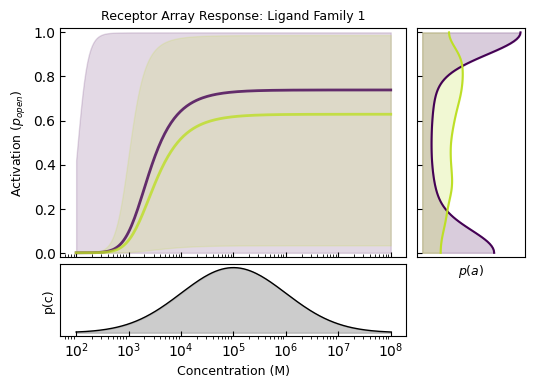

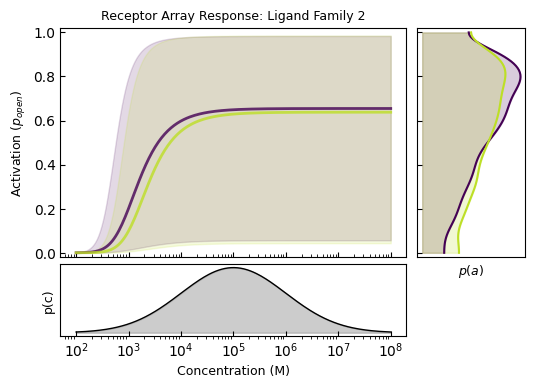

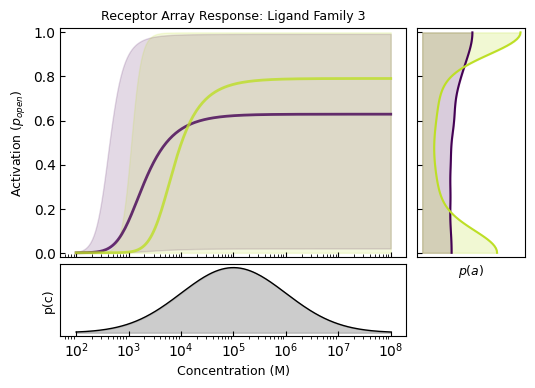

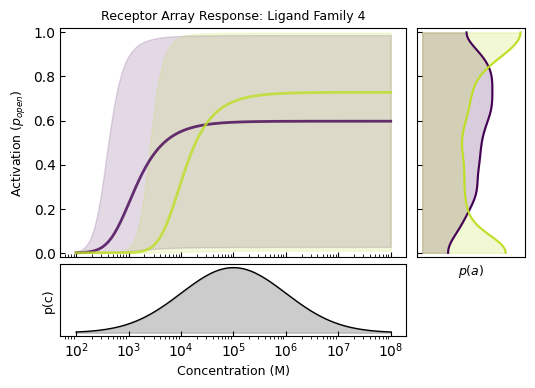

In [7]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)

#with torch.no_grad():
#    E_o = env.interaction_mu.cpu()[:,:,0]
#    E_c = env.interaction_mu.cpu()[:,:,1]
#    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
#for i in range(axes.__len__()):
#    for j in range(asymptot.shape[0]):
#        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])
#for i,fig in enumerate(figs):
#    fig.savefig('2homo_1hetero_'+str(i)+'.svg')
#figs[0].savefig('opti_1r_1l.svg',bbox_inches='tight')

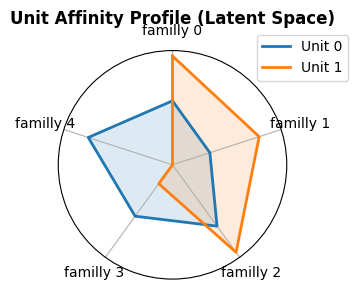

In [ ]:
fig,ax = plot_latent_radar_chart(env, unit_indices=[0, 1], 
                        family_names=['familly '+str(i) for i in range(CONF['n_families'])])
#fig.savefig('latent_space_post_opty.svg',bbox_inches='tight')

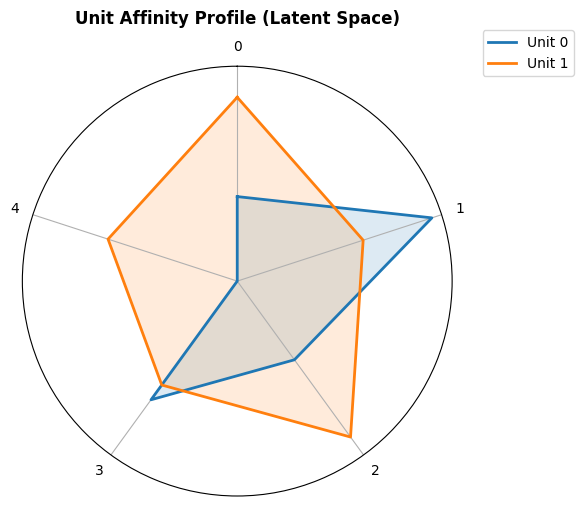

In [23]:
# Compare units 0, 7, and 15 across 8 families
plot_latent_radar_chart(env, unit_indices=[0, 1], 
                        family_names=[str(i) for i in range(CONF['n_families'])])
#plt.savefig('affinity_2homo.svg')

In [38]:
ents = []
N = [10,100,1000,10000]
# sample a bunch of ligands and store the entropy:
evaluated_ent = list()
for n_samples in N:
    ent = list()
    for _ in range(100):
        ent.append(evaluate_model(env=env,physics=physics,receptor_indices=receptor_indices,loss_fn=loss_fn,n_samples=n_samples,k_knn=5).item())
    evaluated_ent.append(ent)

-0.15748794376850128


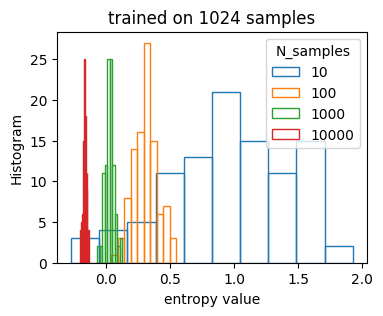

In [46]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONF["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[0]['batch_size']}.svg",transparent=True,bbox_inches='tight')
print(np.mean(ent[-1]))

In [47]:
CONF = {
        "n_units": 2,
        "n_families": 5,
        "latent_dim": 5,
        "k_sub": 5,
        "batch_size": 1024,
        "epochs": 600,
        "lr": 0.05,
        "cov_weight":10.,
        "k_knn":5
    }
# 1. SETUP
# -----------------------------------------------------
# We use 1 Unit, 1 Family. The receptor is a homopentamer (Unit 0 five times).

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Modules
conc_strategy = LogNormalConcentration(n_families=CONF['n_families'], init_mean=5.0)
env = LigandEnvironment(CONF['n_units'], 
                        CONF['n_families'], 
                        conc_model=conc_strategy,
                        latent_dim=CONF['latent_dim']).to(device)

physics = Receptor(CONF["n_units"], CONF["k_sub"]).to(device)
loss_fn = ExactInformationLoss(k_knn=CONF['k_knn']) # Default bandwidth

# Create the receptor identity: [[0, 0, 0, 0, 0]]
#receptor_indices = torch.zeros(1, CONF["k_sub"], dtype=torch.long, device=device)
#receptor_indices = generate_receptor_indices(n_units=CONF['n_units'],k_sub= CONF['k_sub'],n_sensors=2)
receptor_indices = torch.tensor([[0,0,0,0,0],[1,1,1,1,1]],dtype=torch.long)

# Optimizer
optimizer = optim.Adam(list(env.parameters()) + list(physics.parameters()), lr=CONF["lr"])

# 3. OPTIMIZATION LOOP
# -----------------------------------------------------
print(f"Training for {CONF['epochs']} epochs...")

stats_no_hetero = []
for epoch in range(CONF['epochs']):
    optimizer.zero_grad()
    
    # A. Sample Batch
    # energies: (B, 1, 2), concs: (B,)
    energies, concs, _ = env.sample_batch(CONF['batch_size'])
    
    # B. Physics
    # activity: (B, 1)
    activity = physics(energies, concs, receptor_indices)
    

    # C. Loss (Maximize Entropy)
    loss = loss_fn(activity)
    
    loss.backward()
    optimizer.step()
    
    
    if epoch % 10 == 0:
        stats_no_hetero.append(loss_fn.make_stats(activity))
#stats = np.array(stats)
#stats = {
#            "full_array_entropy":stats[:,0],
#            "marginal_entropy":stats[:,1],
#            "total_correlation":stats[:,2]
#        }



Training for 600 epochs...


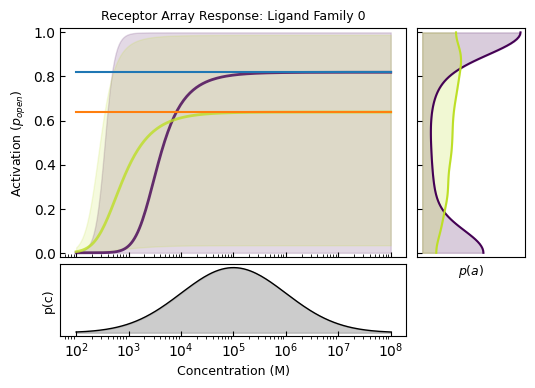

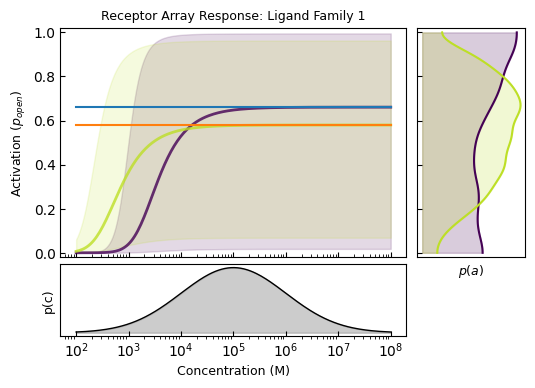

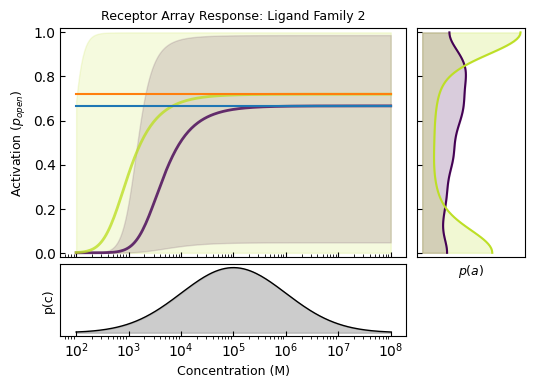

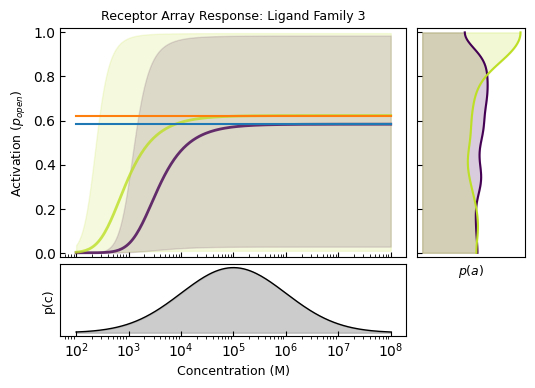

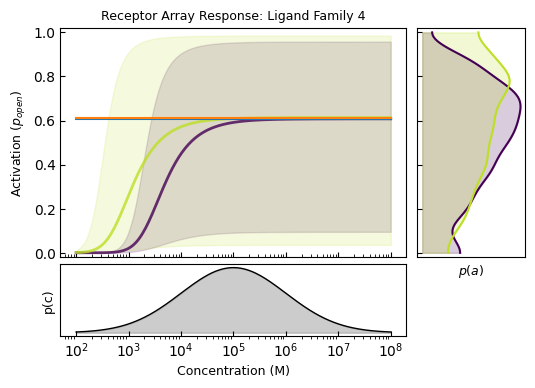

In [30]:
figs,axes = plot_family_summary(env, physics, receptor_indices, loss_fn, n_samples=2000)

with torch.no_grad():
    E_o = env.interaction_mu.cpu()[:,:,0]
    E_c = env.interaction_mu.cpu()[:,:,1]
    asymptot=torch.sigmoid(torch.sum(E_c[receptor_indices] - E_o[receptor_indices],dim=1))
for i in range(axes.__len__()):
    for j in range(asymptot.shape[0]):
        axes[i][0].plot([10**2,10**8],[asymptot[j][i],asymptot[j][i]])

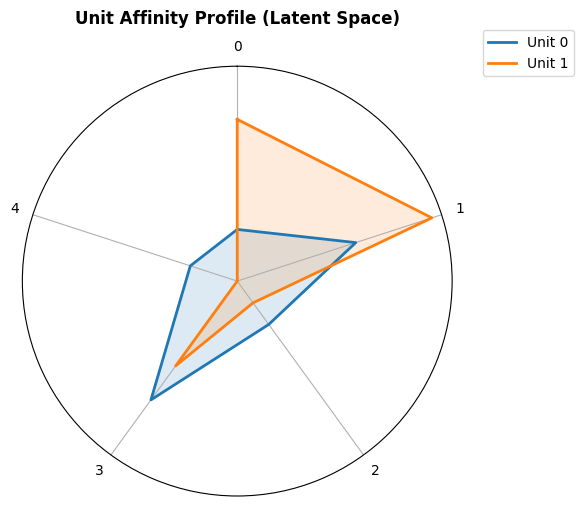

In [31]:
# Compare units 0, 7, and 15 across 8 families
plot_latent_radar_chart(env, unit_indices=[0, 1], 
                        family_names=[str(i) for i in range(CONF['n_families'])])
#plt.savefig('affinity_2homo.svg')

In [48]:
ents = []
N = [10,100,1000,10000]
# sample a bunch of ligands and store the entropy:
evaluated_ent = list()
for n_samples in N:
    ent = list()
    for _ in range(100):
        ent.append(evaluate_model(env=env,physics=physics,receptor_indices=receptor_indices,loss_fn=loss_fn,n_samples=n_samples,k_knn=5).item())
    evaluated_ent.append(ent)

-0.17840103805065155


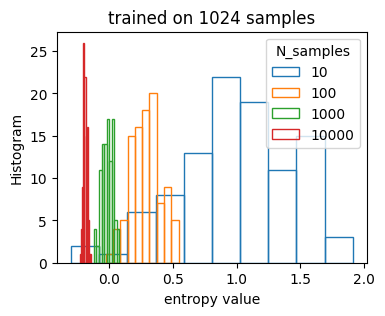

In [49]:
fig,ax = plt.subplots(1,1,figsize=(4,3))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = cycle(prop_cycle.by_key()['color'])
for n,ent in zip(N,evaluated_ent):
    ax.hist(ent,fill=False,edgecolor=next(colors),label=f'{n}')
ax.set_xlabel('entropy value')
ax.set_ylabel('Histogram')
ax.legend(title='N_samples')
ax.set_title(f'trained on {CONF["batch_size"]} samples')
#fig.savefig(f"histogram_test_{CONFs[0]['batch_size']}.svg",transparent=True,bbox_inches='tight')
print(np.mean(ent[-1]))

In [32]:
full_array_ent_1_hetero = [stat['full_array_entropy'] for stat in stats_1_hetero]
full_array_ent_no_hetero = [stat['full_array_entropy'] for stat in stats_no_hetero]

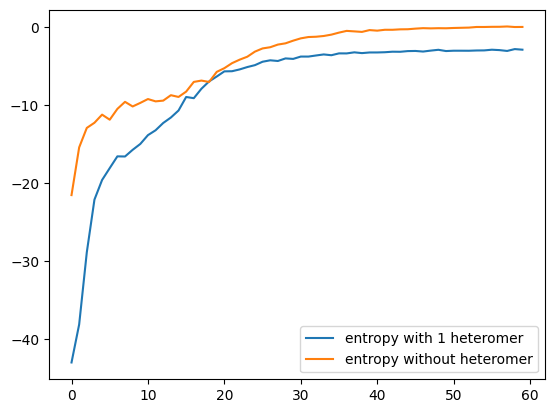

In [33]:
plt.plot(full_array_ent_1_hetero,label="entropy with 1 heteromer")
plt.plot(full_array_ent_no_hetero,label="entropy without heteromer")
plt.legend()

In [11]:
plt.plot(-proxy_loss_history['true_joint_h'],label='approximated loss function')
plt.plot(-exact_loss_history['true_joint_h'],label='exact loss function')
plt.yscale('log')
plt.legend()

NameError: name 'proxy_loss_history' is not defined